In [14]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
datadir0  ='/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/'
plotsdir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Dome/Plots/'
import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [15]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]
    
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    #print(lens)
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        #print(l)
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)
# Example function for exponential decay
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def add_segment(mp_index, t, mean_stress, std_stress, mean_strain, mean_stressZ, std_stressZ):
    t = np.asarray(t, dtype=float).copy()
    mean_stress = np.asarray(mean_stress, dtype=float).copy()
    mean_stressZ = np.asarray(mean_stressZ, dtype=float).copy()
    std_stress  = np.asarray(std_stress, dtype=float).copy()
    std_stressZ  = np.asarray(std_stressZ, dtype=float).copy()
    mean_strain = np.asarray(mean_strain, dtype=float).copy()

    n = min(len(t), len(mean_stress), len(std_stress), len(mean_strain))
    if n == 0:
        return

    stress_segments[mp_index].append(
        (t[:n], mean_stress[:n], std_stress[:n], mean_strain[:n], mean_stressZ[:n], std_stressZ[:n])
    )

def write_mp_file(mp_index, mp_value,nameanchor):
    if len(stress_segments[mp_index]) == 0:
        print("No segments for MP", mp_value)
        return

    t_all      = np.concatenate([seg[0] for seg in stress_segments[mp_index]])
    stress_all = np.concatenate([seg[1] for seg in stress_segments[mp_index]])
    std_all    = np.concatenate([seg[2] for seg in stress_segments[mp_index]])
    strain_all = np.concatenate([seg[3] for seg in stress_segments[mp_index]])
    stress_allZ = np.concatenate([seg[4] for seg in stress_segments[mp_index]])
    std_allZ = np.concatenate([seg[5] for seg in stress_segments[mp_index]])

    order = np.argsort(t_all)

    df = pandas.DataFrame({
        "Time":     t_all[order],
        "AvStress": stress_all[order],
        "StdStress":std_all[order],
        "Strain":   strain_all[order],
        "AvStressZ":   stress_allZ[order],
        "StdStressZ":   std_allZ[order],
    })

    fname = outdir / f"{nameanchor}_MP{mp_value}.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote", fname)



In [16]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']

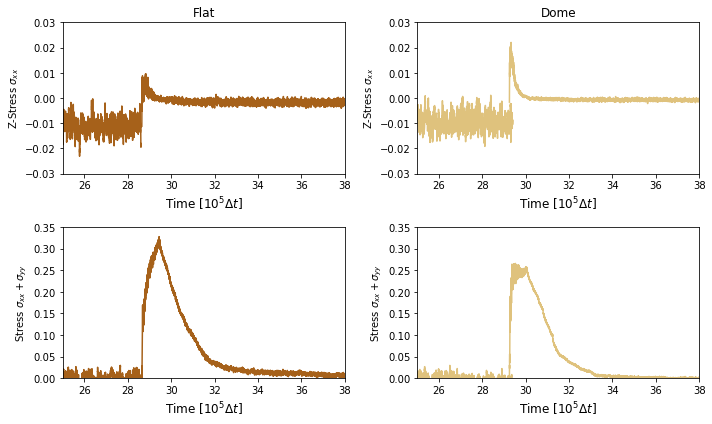

In [ ]:
figNICE,axNICE=plt.subplots(2,2,figsize = (10,6))
tstr = "2e5".split()
Xstretches = "75".split()
folder = 'Data/'
# where to save

Density = True #False
VolInit = (32.3*32.3*12)

for x in range(2):
    for ee in range(2):
        stress_segments = []
        # per-MP list of stress/time arrays from each seed
        stress_traces = []
        stress_traces_Z = []
        strain_traces =[]
        time_traces   = []
            #if s==0 and x==6:
        foldername = datadir0 +folder +'/'
        if x==1:
            if ee==1:
                filename = '/thermo_2.dat'
            else:
                filename = '/thermo_2_equib.dat'
        else:
            if ee==1:
                filename =  '/thermo_flat.dat'
            else:
                filename = '/thermo_flat_equib.dat'

        #print(foldername)
        thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
        press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
        press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
        if ee==1:
            stressXN_,stressYN_,stressZN_ = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
            stressXN,stressYN,stressZN = stressXN_,stressYN_,stressZN_
        CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
        CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
        NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
        NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
        T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
        T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
        
        strain = np.multiply(
            np.subtract(np.sqrt(np.divide(BoxVol, BoxVol[0])), 1.0),
            100.0
        )
        NumTot = thermo.NumTot
        Time_ = thermo.step
        Time = Time_.values
        tStart = Time[0]
        tStr = tStart
        tEndStr = tStr+4.02e5
        tEndRel = tEndStr+1.0e5 #2e5
        time_plot  = np.add(Time,-Time[0])
        filename = '/thermo.dat'
        #tEndRel = tEndStr+5e4 #+1e6
        indexSt = np.argmin(np.abs(Time - tEndRel))
        indexPre = np.argmin(np.abs(Time - tEndStr))
        indexEnd = np.argmin(np.abs(Time - (tEndRel+5e5)))
        #if x==1:

        #print('Time[-1],tEndRel',Time[0],Time[-1],tEndRel,indexSt)
        N=20
        if x==1 and ee==1:
            stressXN = np.where(stressXN > 80000, np.nan, stressXN)
        # print(MPs[mp],Time[0])
        if ee==1:
            stress = np.convolve(np.divide(np.add(stressYN,stressYN),BoxVol), np.ones(N)/N, mode='valid')
            stressZ = np.convolve(np.divide(stressZN,BoxVol), np.ones(N)/N, mode='valid')
        else:
            stress = np.convolve(np.divide(np.add(stressY,stressY),BoxVol), np.ones(N)/N, mode='valid')
            stressZ = np.convolve(np.divide(stressZ,BoxVol), np.ones(N)/N, mode='valid')

        TimeConv = np.convolve(Time, np.ones(N)/N, mode='valid')
        if ee==0:
            SubtractT = TimeConv[0]
        B=0
        if x==0 and ee==0:
            B=2300
        elif x==1 and ee==0:
            B=1000
        else:
            B=10
        axNICE[1,x].plot(np.divide(TimeConv[:-B]-SubtractT,1e5), stress[:-B], color=clrs[x]) 
        axNICE[0,x].plot(np.divide(TimeConv[:-B]-SubtractT,1e5), stressZ[:-B], color=clrs[x]) 
        axNICE[0,x].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
        axNICE[1,x].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
        axNICE[1,x].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$")
        axNICE[0,x].set_ylabel("Z-Stress $\sigma_{xx}$")
        axNICE[1,x].set_ylim([0,0.35])
        axNICE[0,x].set_ylim([-0.03,0.03])
        axNICE[1,x].set_xlim([25,38])
        axNICE[0,x].set_xlim([25,38])



axNICE[0,1].set_title("Dome",fontsize = 12)
axNICE[0,0].set_title("Flat",fontsize = 12)

figNICE.tight_layout()
plotname = "Dome_Stretching.pdf"
#figNICE.savefig(plotsdir+'NewStretch40_profiles.png', dpi=600)
figNICE.savefig(plotsdir+plotname)